# 5. EDA 방법론

- german_credit_risk_data.csv 데이터에 대한 EDA 방법론 진행

- 명목형 변수와 이산형 변수 구분

- 육안 판단, 히스토그램, QQplot, pearson 상관계수, pairplot

In [1]:
# library for feature engineering and EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from IPython.display import Image
from datetime import datetime

# library for statistic
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import uniform as sp_randFloat
from scipy.stats import randint as sp_randInt


# library for sampling
from imblearn.combine import SMOTEENN

# library for machine learning
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

import copy


%matplotlib inline

## 5.1 Data Load

In [2]:
random_state = 1234
raw_df = pd.read_csv("data/german_credit_risk_data.csv", sep=";")
df = copy.deepcopy(raw_df)
print("중복된 항목 수 :", len(df[df.duplicated()]))
df.head()

중복된 항목 수 : 0


,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


In [16]:
# 해당 데이터셋은 threshold 기준으로 나누기가 불가능합니다.


continuous_columns = [
    "Duration_of_Credit_monthly",
    "Credit_Amount",
    "Age_years",
]
discrete_columns = []

for column_name in list(df.columns):
    if column_name not in continuous_columns:
        discrete_columns.append(column_name)
        df[column_name] = df[column_name].astype("object")

    else:
        df[column_name] = df[column_name].astype("int64")
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Creditability                      1000 non-null   object
 1   Account_Balance                    1000 non-null   object
 2   Duration_of_Credit_monthly         1000 non-null   int64 
 3   Payment_Status_of_Previous_Credit  1000 non-null   object
 4   Purpose                            1000 non-null   object
 5   Credit_Amount                      1000 non-null   int64 
 6   Value_Savings_Stocks               1000 non-null   object
 7   Length_of_current_employment       1000 non-null   object
 8   Instalment_per_cent                1000 non-null   object
 9   Sex_Marital_Status                 1000 non-null   object
 10  Guarantors                         1000 non-null   object
 11  Duration_in_Current_address        1000 non-null   object
 12  Most_va

In [18]:
list_categorical_columns = list(df.select_dtypes(include=['object']).columns)
list_numeric_columns = list(df.select_dtypes(include=['int64']).columns)

target_column = "Creditability"

print(len(df.columns))
print(len(list_categorical_columns))
print(len(list_numeric_columns))

21
18
3


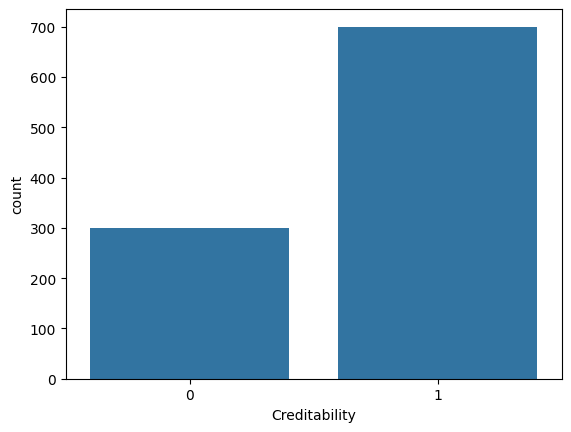

In [19]:
sns.countplot(x=target_column, data=df)
plt.show()

##### Column별 분포 확인

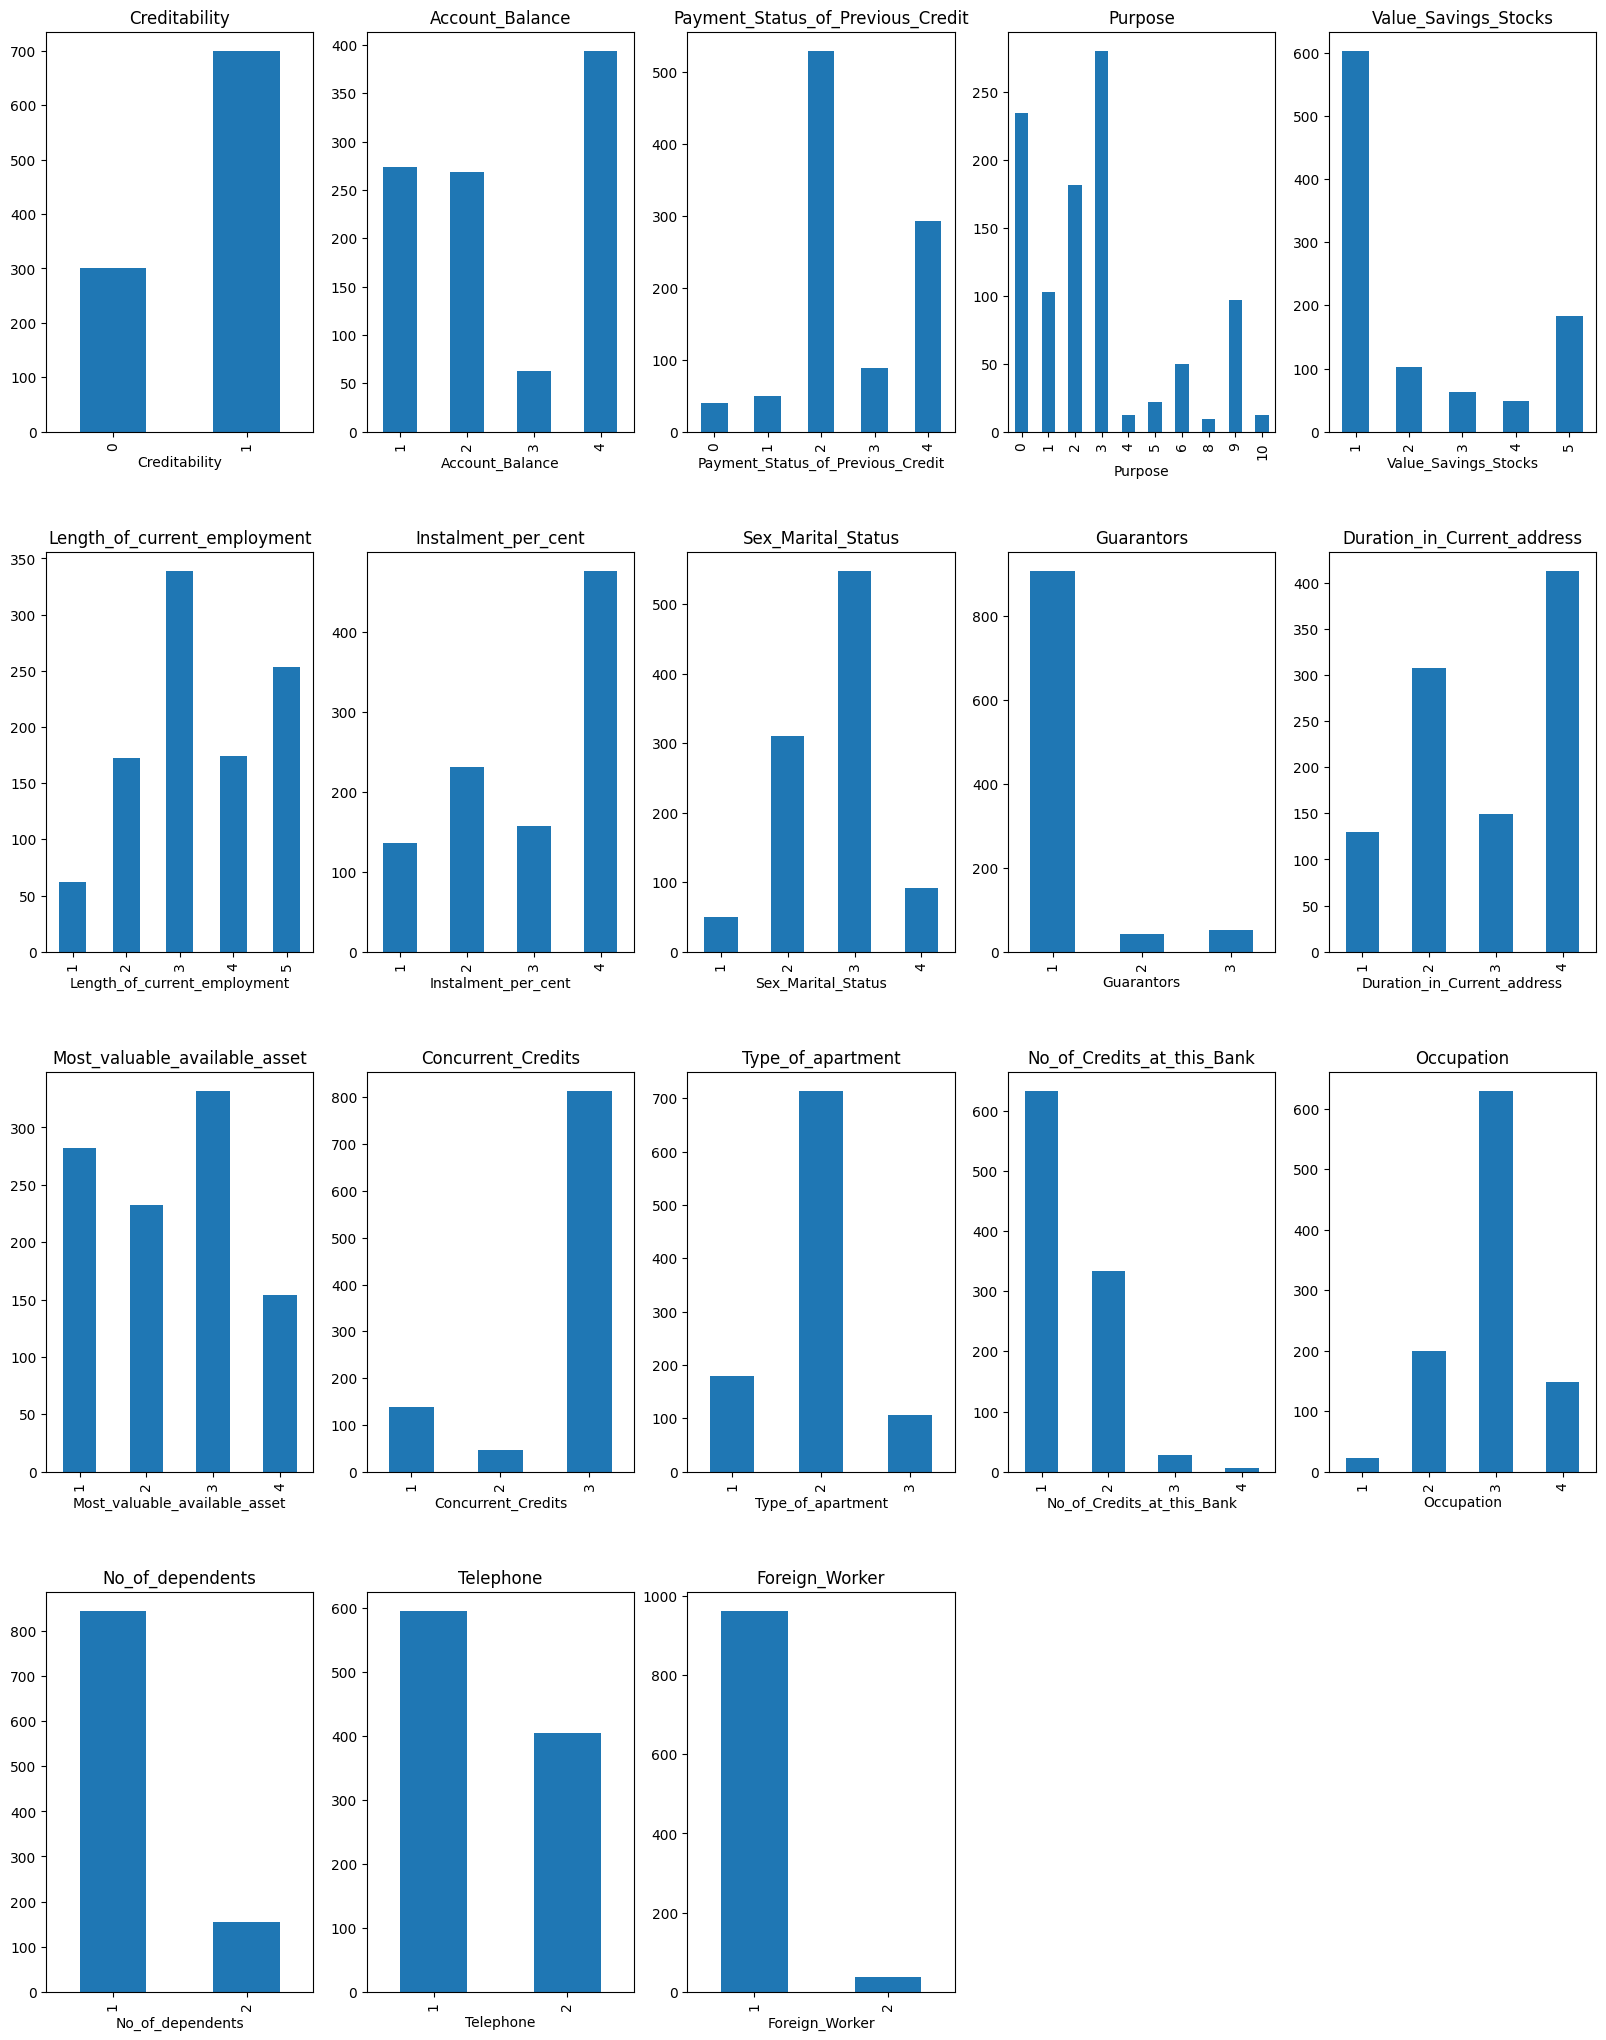

In [11]:
# cateogircla column 별 분포 확인
plt.figure(figsize=(20,20))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.3, wspace=0.2)
for column_name in list_categorical_columns:
    plt.subplot(4,5,x)
    x = x+1
    df[column_name].value_counts().sort_index().plot(kind='bar')
    plt.title(column_name)
plt.show()

##### Target column과 categorical column 관계 분포 확인

<Figure size 3000x3000 with 0 Axes>

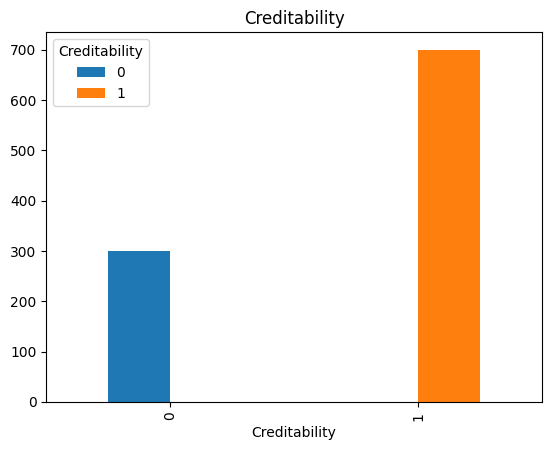

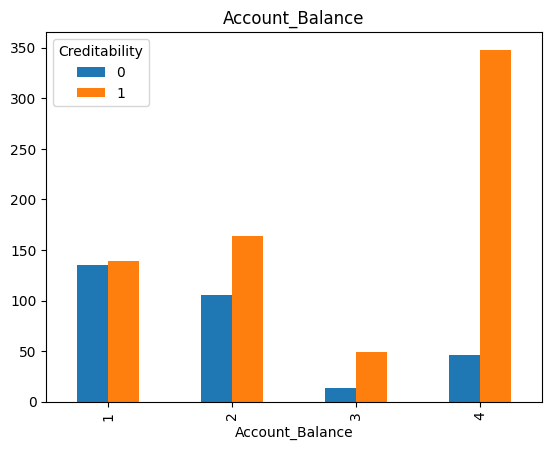

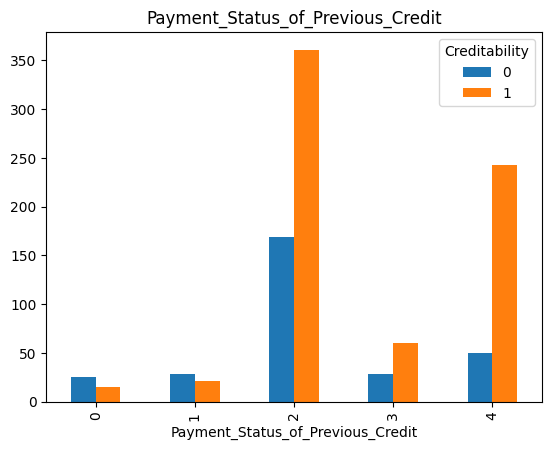

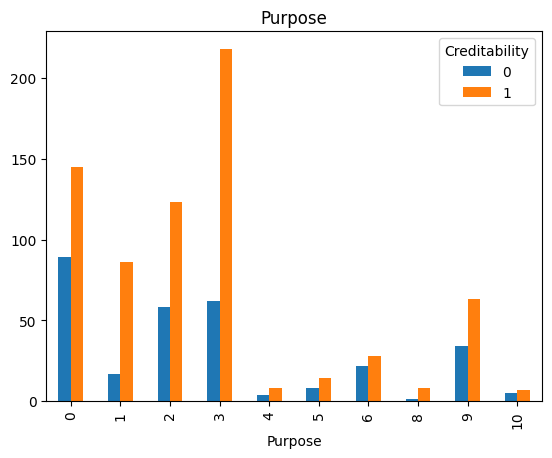

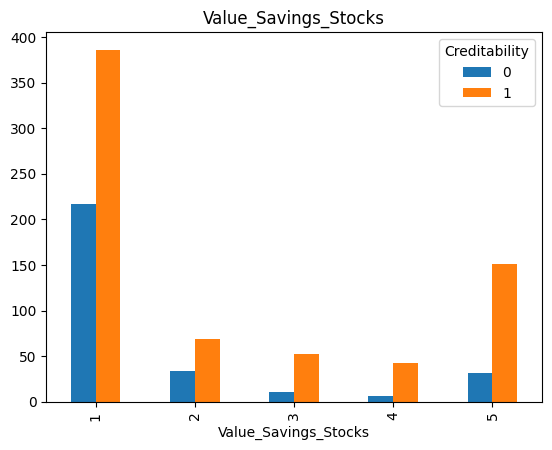

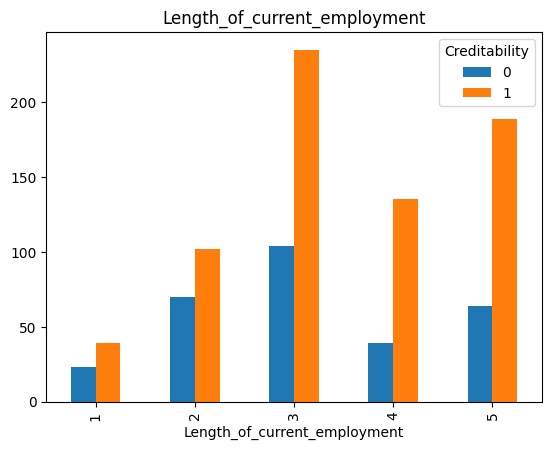

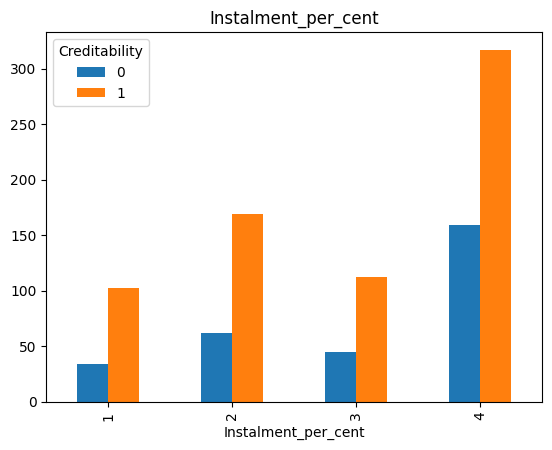

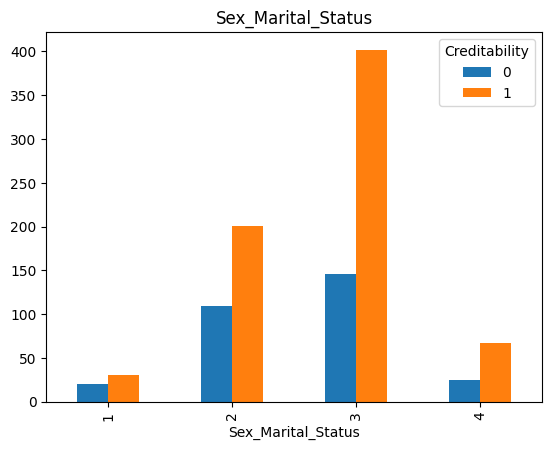

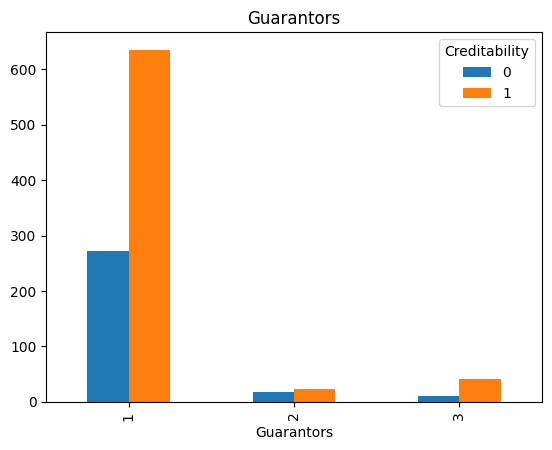

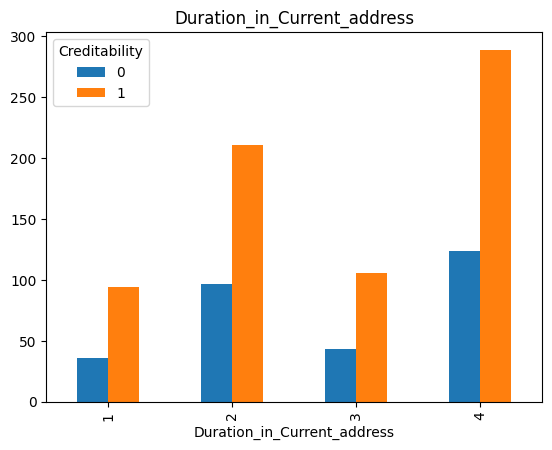

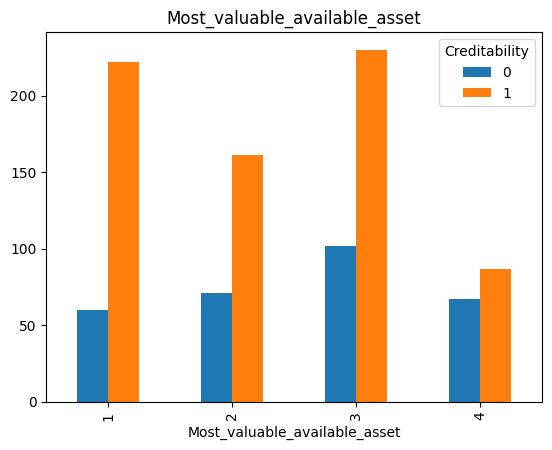

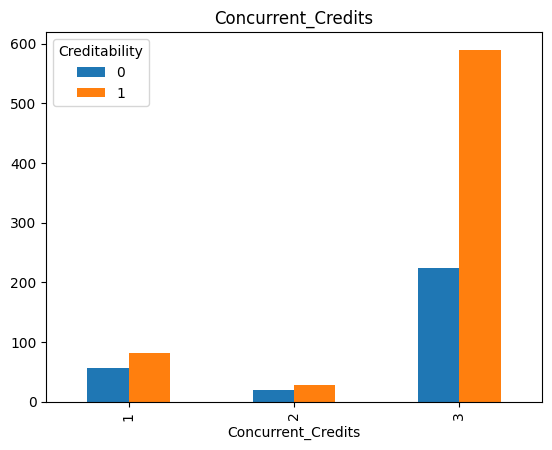

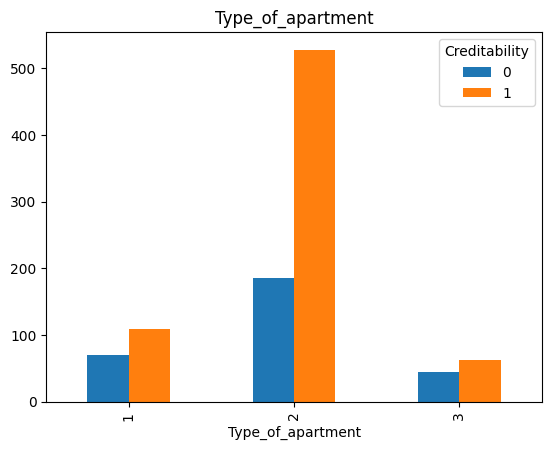

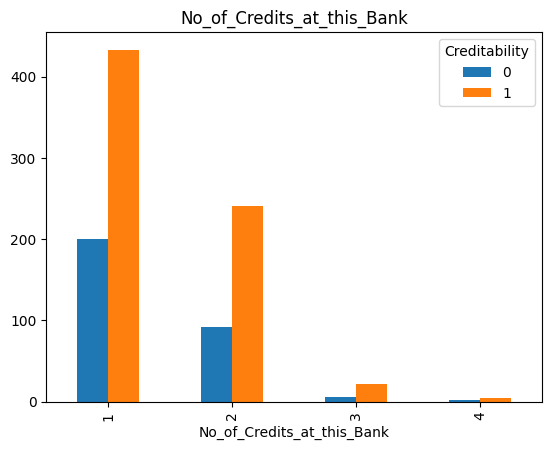

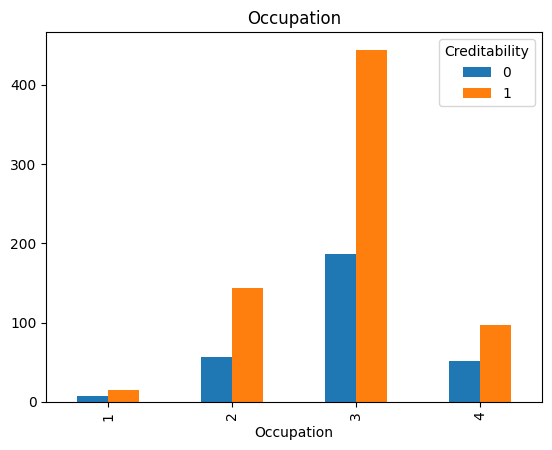

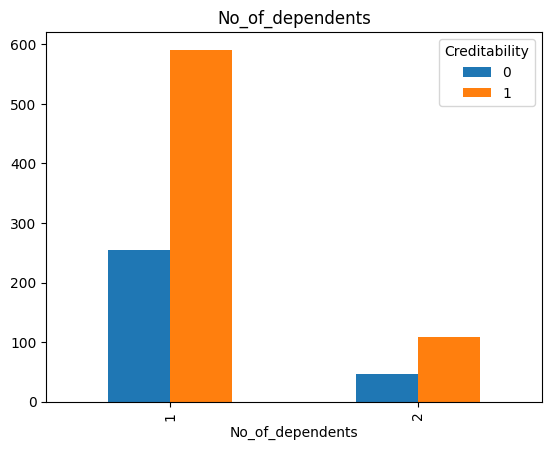

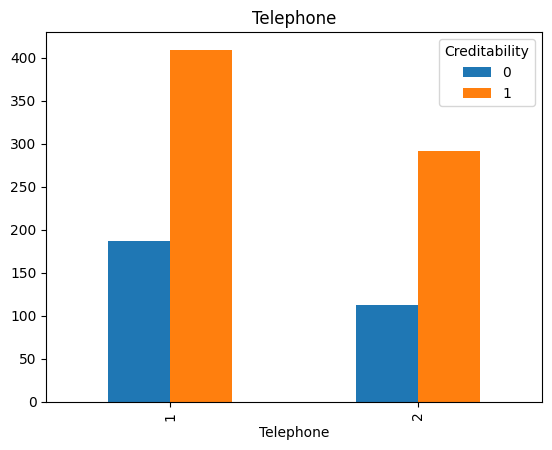

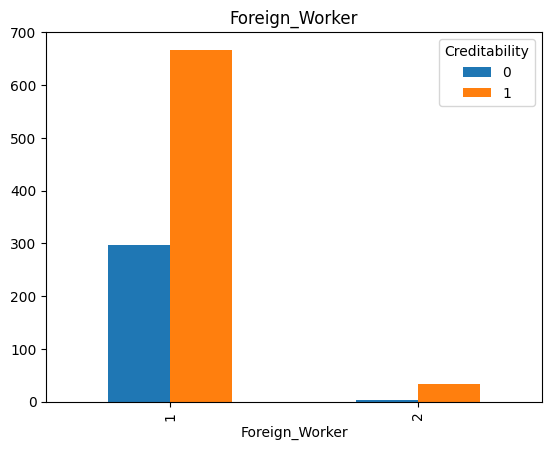

In [12]:
# categorical column과 dependent data(target column) 분포 분석
plt.figure(figsize=(30,30))

for column_name in list_categorical_columns:

    df.groupby([column_name, "Creditability"]).count().iloc[:,0].unstack().plot(kind='bar')
    plt.title(column_name)

plt.show()

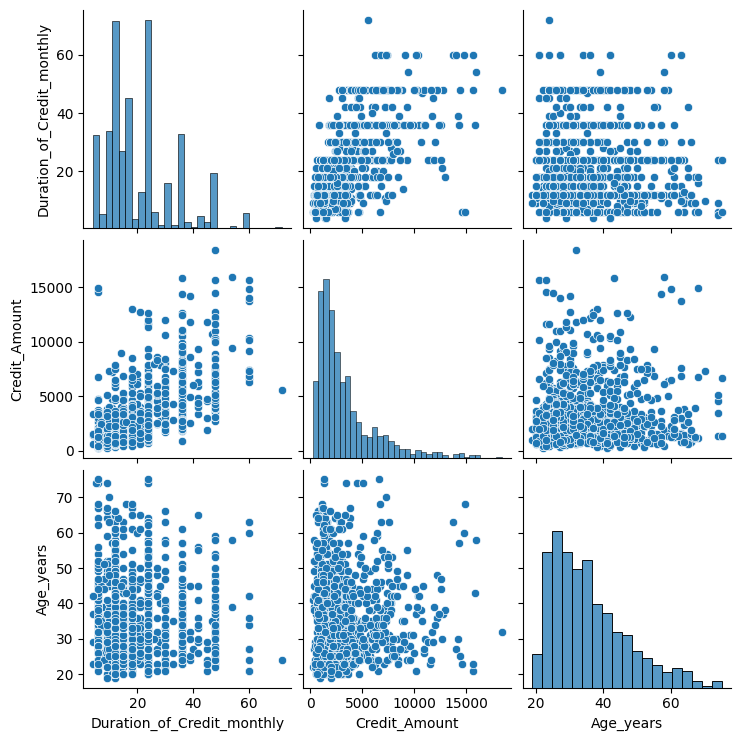

In [13]:
sns.pairplot(data=df.loc[:, list_numeric_columns])

# 1. 대출 희망 금액이 많아질 수록, 대출 희망 기간도 늘어나는 경향을 보임
# 2. 저축액과 소득대비 상환 납입비율은 상관이 없어 보임
# 3. 해당 은행에 대출이 3개 이상 있는 사람은 대출 희망 기간을 길게 하지 않음

##### Correlation Analysis

<Axes: >

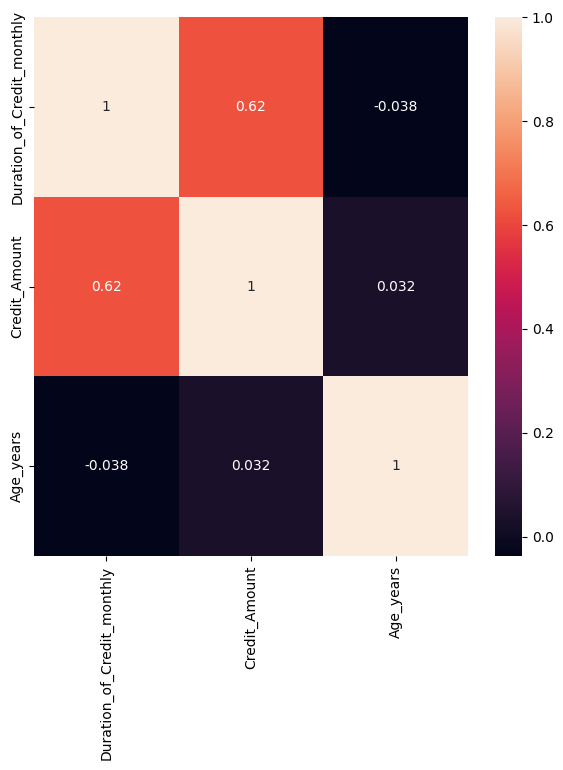

In [14]:
plt.figure(figsize=(7,7))
sns.heatmap(df[list_numeric_columns].corr(), annot=True)

##### Target Column과 numeric Column 관계 분포 확인

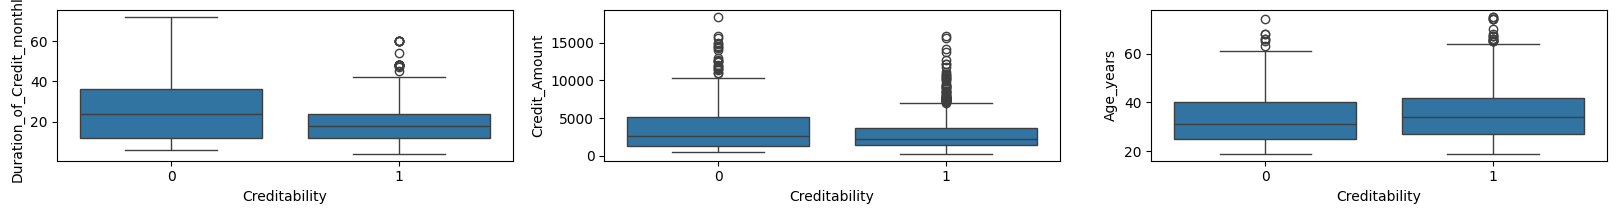

In [15]:
plt.figure(figsize=(20,20))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.5, wspace=0.2)
for column_name in list_numeric_columns:
    plt.subplot(9,3,x)
    x = x + 1
    sns.boxplot(data=df,x='Creditability',y=column_name)
plt.show()

##### 크루스칼 왈리스 검정 Kruskall-Wallis test (비모수 검정)
*   비모수 검정이기 때문에 정규성/등분산성을 만족하지 않아도됨
*   단, 비모수 검정이기 때문에 검정 결과 신뢰도가 모수 검정보다 떨어짐

In [29]:
# kruskall 검정
list_meaningful_column_by_kruskall = []

for column_name in list_numeric_columns:
  list_by_value = []
  for value in df[target_column].dropna().unique():
      df_tmp = df[df[target_column] == value][column_name].dropna()
      list_by_value.append(np.array(df_tmp))
  statistic, pvalue = kruskal(*list_by_value)
  if pvalue <= 0.05:
    list_meaningful_column_by_kruskall.append(column_name)
  print(column_name, ", ",statistic,", ", pvalue)
print("all categorical columns : ", len(list_numeric_columns))
print("selected columns by kruskal : ", len(list_meaningful_column_by_kruskall), list_meaningful_column_by_kruskall)

Duration_of_Credit_monthly ,  42.263859684710084 ,  7.975280722435737e-11
Credit_Amount ,  7.575879507631307 ,  0.005915450904320812
Value_Savings_Stocks ,  30.663570435469385 ,  3.0687280146351794e-08
Instalment_per_cent ,  5.424750145998911 ,  0.01985327596986272
Age_years ,  12.810120621447924 ,  0.00034474934315396557
No_of_Credits_at_this_Bank ,  2.236544135434218 ,  0.13478191734200565
all categorical columns :  6
selected columns by kruskal :  5 ['Duration_of_Credit_monthly', 'Credit_Amount', 'Value_Savings_Stocks', 'Instalment_per_cent', 'Age_years']


##### Insight
1.   Creditability(종속 변수)와 유의미한 관계를 갖지 않는 numerical data가 확인됨 (6개중 5개가 유의미한 교호작용을 보임)
2.   feature selection 및 model optimization을 위해 1번에서 얻은 결과를 활용
3.   numercial data 간의 상관관계 중, 높은 상관 관계를 갖는 경우는 없다.
4.   numerical data 들은 skew 값보다 kurtosis 값이 큰 경향을 보이는 것들이 존재한다. 이는 preprocessing으로 데이터 분포를 정규화 할 수 있다.



## 3. Data Processing 2

### 3-1 Missing Values

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Creditability                      1000 non-null   object
 1   Account_Balance                    1000 non-null   object
 2   Duration_of_Credit_monthly         1000 non-null   int64 
 3   Payment_Status_of_Previous_Credit  1000 non-null   object
 4   Purpose                            1000 non-null   object
 5   Credit_Amount                      1000 non-null   int64 
 6   Value_Savings_Stocks               1000 non-null   int64 
 7   Length_of_current_employment       1000 non-null   object
 8   Instalment_per_cent                1000 non-null   int64 
 9   Sex_Marital_Status                 1000 non-null   object
 10  Guarantors                         1000 non-null   object
 11  Duration_in_Current_address        1000 non-null   object
 12  Most_va

In [31]:
df.isna().sum().sort_values(ascending=False)

Creditability                        0
Duration_in_Current_address          0
Telephone                            0
No_of_dependents                     0
Occupation                           0
No_of_Credits_at_this_Bank           0
Type_of_apartment                    0
Concurrent_Credits                   0
Age_years                            0
Most_valuable_available_asset        0
Guarantors                           0
Account_Balance                      0
Sex_Marital_Status                   0
Instalment_per_cent                  0
Length_of_current_employment         0
Value_Savings_Stocks                 0
Credit_Amount                        0
Purpose                              0
Payment_Status_of_Previous_Credit    0
Duration_of_Credit_monthly           0
Foreign_Worker                       0
dtype: int64

### 3-2 Encoding and Feature Selection

In [32]:
Y = df[target_column]
X = df.drop([target_column], axis=1)

##### Label Encoding

In [33]:
Y

0      1
1      1
2      1
3      1
4      1
      ..
995    0
996    0
997    0
998    0
999    0
Name: Creditability, Length: 1000, dtype: object

In [34]:
le_encoder = LabelEncoder()
Y_encoded = le_encoder.fit_transform(Y)
Y_encoded

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

##### Feature Selection

In [35]:
X_fs = df[list_meaningful_column_by_chi+list_meaningful_column_by_kruskall]
X_fs

,Account_Balance,Payment_Status_of_Previous_Credit,Purpose,Length_of_current_employment,Sex_Marital_Status,Guarantors,Most_valuable_available_asset,Concurrent_Credits,Type_of_apartment,Foreign_Worker,Duration_of_Credit_monthly,Credit_Amount,Value_Savings_Stocks,Instalment_per_cent,Age_years
0,1,4,2,2,2,1,2,3,1,1,18,1049,1,4,21
1,1,4,0,3,3,1,1,3,1,1,9,2799,1,2,36
2,2,2,9,4,2,1,1,3,1,1,12,841,2,2,23
3,1,4,0,3,3,1,1,3,1,2,12,2122,1,3,39
4,1,4,0,3,3,1,2,1,2,2,12,2171,1,4,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,2,3,3,3,1,1,3,1,1,24,1987,1,2,21
996,1,2,0,5,3,2,1,3,2,1,24,2303,1,4,45
997,4,4,0,5,3,1,4,3,3,1,21,12680,5,4,30
998,2,2,3,1,3,1,4,3,2,1,12,6468,5,2,52


In [36]:
print(len(X.columns))
print(len(X_fs.columns))

20
15


##### Feature Transformation
*   Standardization과 Normalization은 다른 것.
*   Normalization은 [0,1]로 값을 scaling 하는 것 (예 sklearn의 MinMaxScaler())
*   Standardization은 정규분포의 표준화를 활용하여 scaling하는 것 (예 sklearn의 StandardScaler())



In [37]:
X_fs.head(2)

,Account_Balance,Payment_Status_of_Previous_Credit,Purpose,Length_of_current_employment,Sex_Marital_Status,Guarantors,Most_valuable_available_asset,Concurrent_Credits,Type_of_apartment,Foreign_Worker,Duration_of_Credit_monthly,Credit_Amount,Value_Savings_Stocks,Instalment_per_cent,Age_years
0,1,4,2,2,2,1,2,3,1,1,18,1049,1,4,21
1,1,4,0,3,3,1,1,3,1,1,9,2799,1,2,36


In [38]:
scaler = StandardScaler()
X_fs.loc[:, list_meaningful_column_by_kruskall] = scaler.fit_transform(X_fs[list_meaningful_column_by_kruskall])
X_fs.head(2)

<ipython-input-38-1434b7a07ea7>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_fs.loc[:, list_meaningful_column_by_kruskall] = scaler.fit_transform(X_fs[list_meaningful_column_by_kruskall])


,Account_Balance,Payment_Status_of_Previous_Credit,Purpose,Length_of_current_employment,Sex_Marital_Status,Guarantors,Most_valuable_available_asset,Concurrent_Credits,Type_of_apartment,Foreign_Worker,Duration_of_Credit_monthly,Credit_Amount,Value_Savings_Stocks,Instalment_per_cent,Age_years
0,1,4,2,2,2,1,2,3,1,1,-0.240857,-0.787657,-0.699707,0.918477,-1.281573
1,1,4,0,3,3,1,1,3,1,1,-0.987573,-0.167384,-0.699707,-0.870183,0.040363


In [39]:
X.loc[:, list_numeric_columns] = scaler.fit_transform(X[list_numeric_columns])
X.head(2)

,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,Guarantors,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
0,1,-0.240857,4,2,-0.787657,-0.699707,2,0.918477,2,1,4,2,-1.281573,3,1,-0.704926,3,1,1,1
1,1,-0.987573,4,0,-0.167384,-0.699707,3,-0.870183,3,1,2,1,0.040363,3,1,1.027079,3,2,1,1


In [40]:
# MinMaxScaler Test
minmax_scaler = MinMaxScaler()
print(minmax_scaler.fit_transform(X_fs[list_meaningful_column_by_kruskall])[:2,:])

[[0.20588235 0.0439639  0.         1.         0.03571429]
 [0.07352941 0.14025531 0.         0.33333333 0.30357143]]


##### One-hot Encoding for categorical column data

In [41]:
X_base = pd.get_dummies(X)
X_fs_final = pd.get_dummies(X_fs)

<ipython-input-41-a6b2f43527bd>:1: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  X_base = pd.get_dummies(X)
<ipython-input-41-a6b2f43527bd>:1: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  X_base = pd.get_dummies(X)
<ipython-input-41-a6b2f43527bd>:1: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  X_base = pd.get_dummies(X)
<ipython-input-41-a6b2f43527bd>:1: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  X_base = pd.get_dummies(X)
<ipython-input-41-a6b2f43527bd>:1: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dt

In [42]:
X_fs_final.columns

Index(['Duration_of_Credit_monthly', 'Credit_Amount', 'Value_Savings_Stocks',
       'Instalment_per_cent', 'Age_years', 'Account_Balance_1',
       'Account_Balance_2', 'Account_Balance_3', 'Account_Balance_4',
       'Payment_Status_of_Previous_Credit_0',
       'Payment_Status_of_Previous_Credit_1',
       'Payment_Status_of_Previous_Credit_2',
       'Payment_Status_of_Previous_Credit_3',
       'Payment_Status_of_Previous_Credit_4', 'Purpose_0', 'Purpose_1',
       'Purpose_2', 'Purpose_3', 'Purpose_4', 'Purpose_5', 'Purpose_6',
       'Purpose_8', 'Purpose_9', 'Purpose_10',
       'Length_of_current_employment_1', 'Length_of_current_employment_2',
       'Length_of_current_employment_3', 'Length_of_current_employment_4',
       'Length_of_current_employment_5', 'Sex_Marital_Status_1',
       'Sex_Marital_Status_2', 'Sex_Marital_Status_3', 'Sex_Marital_Status_4',
       'Guarantors_1', 'Guarantors_2', 'Guarantors_3',
       'Most_valuable_available_asset_1', 'Most_valuable_availab

In [43]:
X_fs_final.head(2)

,Duration_of_Credit_monthly,Credit_Amount,Value_Savings_Stocks,Instalment_per_cent,Age_years,Account_Balance_1,Account_Balance_2,Account_Balance_3,Account_Balance_4,Payment_Status_of_Previous_Credit_0,...,Most_valuable_available_asset_3,Most_valuable_available_asset_4,Concurrent_Credits_1,Concurrent_Credits_2,Concurrent_Credits_3,Type_of_apartment_1,Type_of_apartment_2,Type_of_apartment_3,Foreign_Worker_1,Foreign_Worker_2
0,-0.240857,-0.787657,-0.699707,0.918477,-1.281573,1,0,0,0,0,...,0,0,0,0,1,1,0,0,1,0
1,-0.987573,-0.167384,-0.699707,-0.870183,0.040363,1,0,0,0,0,...,0,0,0,0,1,1,0,0,1,0


In [44]:
X_base.head(2)

,Duration_of_Credit_monthly,Credit_Amount,Value_Savings_Stocks,Instalment_per_cent,Age_years,No_of_Credits_at_this_Bank,Account_Balance_1,Account_Balance_2,Account_Balance_3,Account_Balance_4,...,Occupation_1,Occupation_2,Occupation_3,Occupation_4,No_of_dependents_1,No_of_dependents_2,Telephone_1,Telephone_2,Foreign_Worker_1,Foreign_Worker_2
0,-0.240857,-0.787657,-0.699707,0.918477,-1.281573,-0.704926,1,0,0,0,...,0,0,1,0,1,0,1,0,1,0
1,-0.987573,-0.167384,-0.699707,-0.870183,0.040363,1.027079,1,0,0,0,...,0,0,1,0,0,1,1,0,1,0


##### Sampling for imbalanced data (combined samping)
*   SMOTEENN : SMOTE + ENN
*   https://imbalanced-learn.org/stable/references/generated/imblearn.combine.SMOTEENN.html

In [46]:
X_fs_final_train, X_fs_final_validation, y_fs_final_train, y_fs_final_validation = train_test_split(X_fs_final, Y_encoded, stratify=Y_encoded)

In [47]:
# To do

sme = SMOTEENN(random_state=random_state)
X_fs_sme_sampling, y_sme_sampling = sme.fit_resample(X_fs_final_train, y_fs_final_train)


Text(0.5, 1.0, 'After sampling for target label')

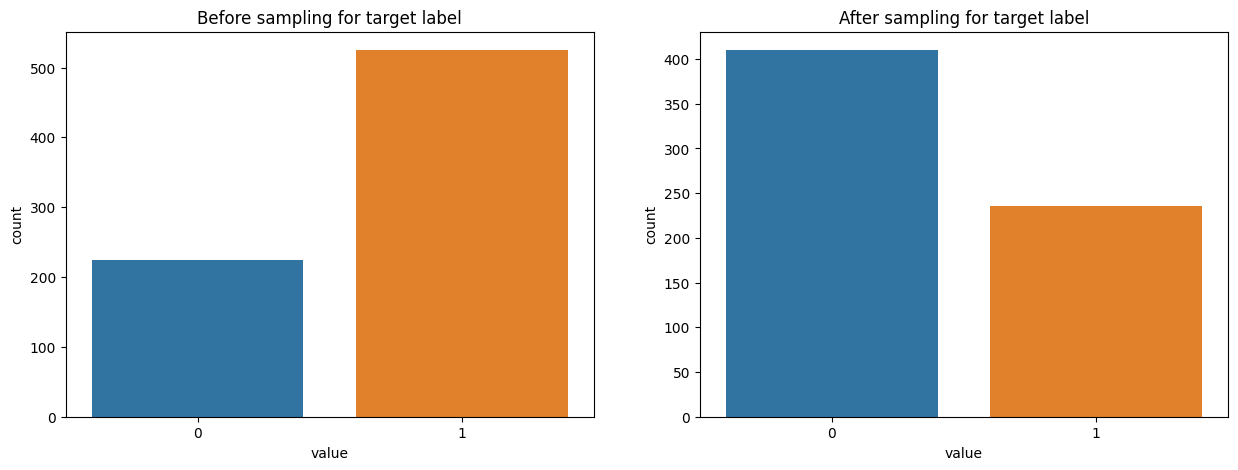

In [48]:
fig = plt.figure(figsize=(15,5))
fig.add_subplot(121)
df_tmp = pd.DataFrame(y_fs_final_train, columns=['value'])
sns.countplot(x='value', data=df_tmp)
plt.title("Before sampling for target label")

fig.add_subplot(122)
df_tmp = pd.DataFrame(y_sme_sampling, columns=['value'])
sns.countplot(x='value', data=df_tmp)
plt.title("After sampling for target label")

### 3-3 Feature Reduction

In [45]:
from sklearn.decomposition import PCA

In [49]:
pca = PCA(n_components=2)  # 2차원으로 축소
X_pca = pca.fit_transform(np.array(X_fs_sme_sampling))

# 변환된 데이터의 형태를 확인
print("Original shape:", np.array(X_fs_sme_sampling).shape)
print("Reduced shape:", X_pca.shape)


Original shape: (646, 48)
Reduced shape: (646, 2)


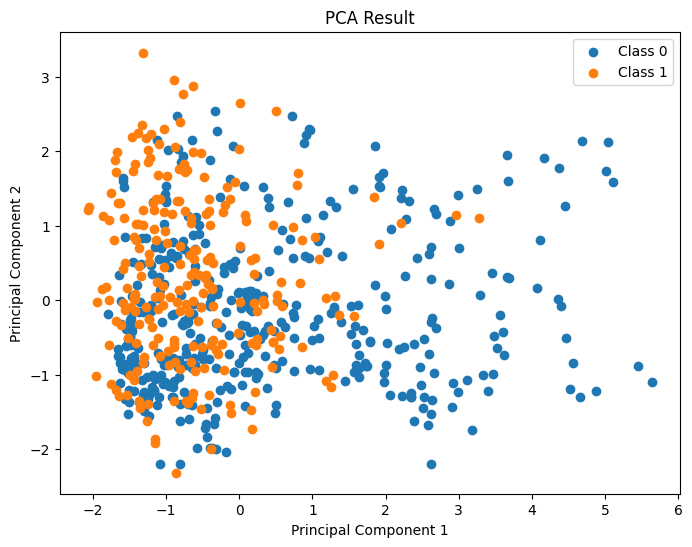

In [50]:
plt.figure(figsize=(8, 6))

# 고유한 클래스 레이블을 얻기 위해 set을 사용합니다.
unique_labels = set(y_sme_sampling)

for label in unique_labels:
    # 각 클래스에 대한 데이터 포인트를 추출합니다.
    idx = y_sme_sampling == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f'Class {label}')

# 축 레이블과 제목 추가
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result')

# 범례 추가
plt.legend()

# 그래프 보여주기
plt.show()